In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import pymannkendall as mk
import pyhomogeneity as hg
from scipy.special import comb
import numpy as np
import random
from scipy.stats import gumbel_r

In [62]:
# ESTA CÉLULA SERVE PARA EXTRAIR OS MÁXIMOS ANUAIS

# informar código das estações
estacoes = (64820000,
64830000,
65025000,
65945000,
81125000)

# extraindo máximos anuais das séries
for i in range(len(estacoes)):

    df = pd.read_csv(f'C:\\camels\\02_CAMELS_BR_streamflow_all_catchments\\{estacoes[i]}_streamflow.txt', sep=r'\s+')
    
    df['date'] = pd.to_datetime({
            'year': df['year'],
            'month': df['month'],
            'day': df['day']})
    
    df = df.sort_values('date').reset_index(drop=True)
    df['ano'] = df['date'].dt.year
    
    df = df[(df['ano'] != 2024) & (df['ano'] != df['ano'].min())]
    
        # índice do máximo anual
    idx_max = df.groupby('ano')['streamflow_m3s'].idxmax()
    
    max_anual = df.loc[idx_max, ['ano', 'date', 'streamflow_m3s']].copy()
    max_anual.to_csv(f'C:\\Users\\mateu\\OneDrive\\Área de Trabalho\\artigos_2026\\analise_incerteza\\vazoes_maximas_anuais\\{estacoes[i]}.csv')

    plt.plot(max_anual['ano'],max_anual['streamflow_m3s'])
    plt.xlabel('Tempo (ano)')
    plt.ylabel('Vazão (m³/s)')
    plt.grid()
    plt.savefig(f'C:\\Users\\mateu\\OneDrive\\Área de Trabalho\\artigos_2026\\analise_incerteza\\vazoes_maximas_anuais\\{estacoes[i]}_serietemporal.png')
    plt.close()

    plot_acf(
    max_anual['streamflow_m3s'],
    lags=min(20, len(max_anual['streamflow_m3s'])//2),
    alpha=0.05
    )
    plt.xlabel('Defasagem (anos)')
    plt.ylabel('Autocorrelação')
    plt.title('Correlograma das Vazões Máximas Anuais')
    plt.savefig(f'C:\\Users\\mateu\\OneDrive\\Área de Trabalho\\artigos_2026\\analise_incerteza\\vazoes_maximas_anuais\\{estacoes[i]}_correlograma.png')
    plt.close()


Ano de quebra: 1986
p-valor: 0.0013


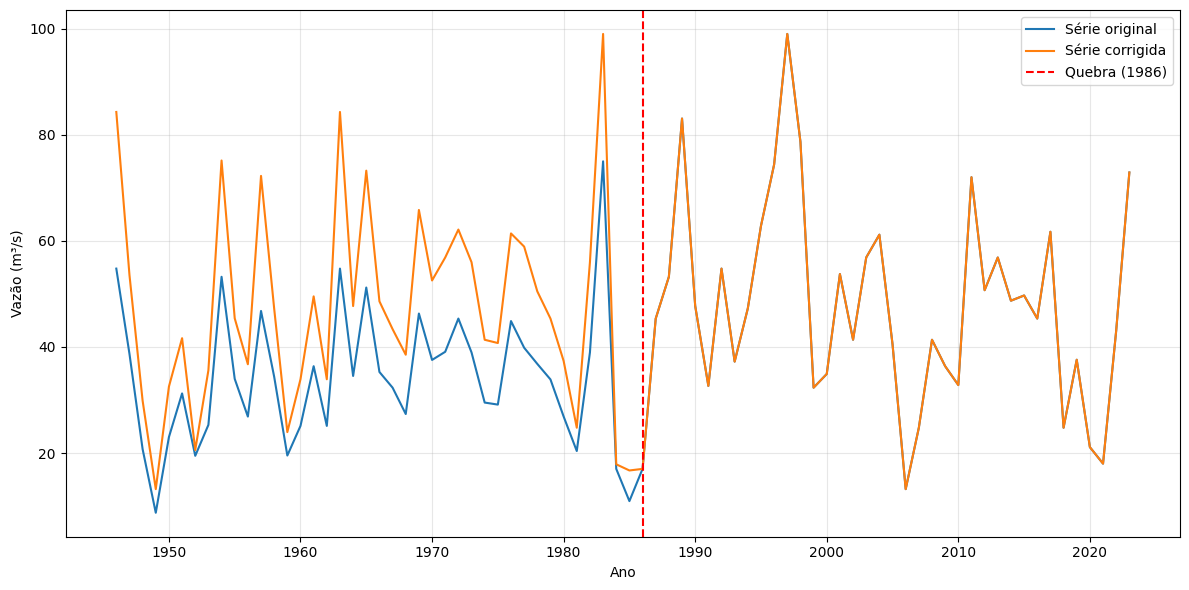

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyhomogeneity as hg
from scipy.interpolate import interp1d

# =============================================================================
# Leitura dos dados
# =============================================================================

max_anual = pd.read_csv(
    r"C:\Users\mateu\OneDrive\Área de Trabalho\artigos_2026\analise_incerteza\vazoes_maximas_anuais\81125000.csv"
)

# =============================================================================
# Pettitt
# =============================================================================

resultado = hg.pettitt_test(max_anual['streamflow_m3s'])

ano_quebra = max_anual['ano'].iloc[resultado.cp-1]

print(f'Ano de quebra: {ano_quebra}')
print(f'p-valor: {resultado.p}')

# =============================================================================
# Separação das séries
# =============================================================================

serie_antiga = max_anual[max_anual['ano'] < ano_quebra].copy()
serie_nova   = max_anual[max_anual['ano'] >= ano_quebra].copy()

# =============================================================================
# Curvas de permanência (CDF empírica)
# =============================================================================

x_old = np.sort(serie_antiga['streamflow_m3s'])
p_old = (np.arange(1, len(x_old)+1)-0.44)/(len(x_old)+0.12)

x_new = np.sort(serie_nova['streamflow_m3s'])
p_new = (np.arange(1, len(x_new)+1)-0.44)/(len(x_new)+0.12)

# Funções de interpolação
cdf_old = interp1d(
    x_old,
    p_old,
    bounds_error=False,
    fill_value=(p_old[0], p_old[-1])
)

inv_cdf_new = interp1d(
    p_new,
    x_new,
    bounds_error=False,
    fill_value=(x_new[0], x_new[-1])
)

# =============================================================================
# Correção da série anterior à quebra
# =============================================================================

probabilidades = cdf_old(serie_antiga['streamflow_m3s'])

serie_antiga['streamflow_corrigida'] = inv_cdf_new(probabilidades)

# =============================================================================
# Montando série final corrigida
# =============================================================================

serie_corrigida = max_anual.copy()

serie_corrigida['streamflow_corrigida'] = (
    serie_corrigida['streamflow_m3s']
)

mask = serie_corrigida['ano'] < ano_quebra

serie_corrigida.loc[
    mask,
    'streamflow_corrigida'
] = serie_antiga['streamflow_corrigida'].values

# =============================================================================
# Figura comparativa
# =============================================================================

plt.figure(figsize=(12,6))

plt.plot(
    serie_corrigida['ano'],
    serie_corrigida['streamflow_m3s'],
    label='Série original'
)

plt.plot(
    serie_corrigida['ano'],
    serie_corrigida['streamflow_corrigida'],
    label='Série corrigida'
)

plt.axvline(
    ano_quebra,
    color='red',
    linestyle='--',
    label=f'Quebra ({ano_quebra})'
)

plt.xlabel('Ano')
plt.ylabel('Vazão (m³/s)')
plt.grid(True, alpha=0.3)
plt.legend()


plt.tight_layout()
plt.savefig(f'C:\\Users\\mateu\\OneDrive\\Área de Trabalho\\artigos_2026\\analise_incerteza\\serie_corr_orig.png')

In [3]:
# Ajuste por meio de Gumbel por momentos-L
serie_original = serie_corrigida[['streamflow_m3s']]
serie_corr = serie_corrigida[['streamflow_corrigida']]

serie_original = serie_original.sort_values('streamflow_m3s').reset_index()
serie_corr = serie_corr.sort_values('streamflow_corrigida').reset_index()

lista_i = list(range(1,len(serie_original.streamflow_m3s)+1))
N = len(lista_i)
serie_original['i'] = lista_i
serie_corr['i'] = lista_i

#calculo de a0
a0_original = np.mean(serie_original.streamflow_m3s)
a0_corrigido = np.mean(serie_corr.streamflow_corrigida)

#calculo de a1
r = 1
divisor = comb(N-1,r)
serie_original['bin_1'] = (
    comb(N - serie_original['i'], r)
    * serie_original['streamflow_m3s']
)

serie_corr['bin_1'] = (
    comb(N - serie_corr['i'], r)
    * serie_corr['streamflow_corrigida']
)

a1_original = (serie_original['bin_1'].sum()/divisor)/N
a1_corrigido = (serie_corr['bin_1'].sum()/divisor)/N

#calculando os momentos 
l1_original = a0_original
l2_original = a0_original - 2*a1_original

l1_corrigido = a0_corrigido
l2_corrigido = a0_corrigido - 2*a1_corrigido

#estimativa de parâmetros Gumbel 
alfa_original = l2_original/np.log(2)
beta_original = l1_original-(0.5772*alfa_original)

alfa_corrigido = l2_corrigido/np.log(2)
beta_corrigido = l1_corrigido-0.5772*alfa_corrigido

print(alfa_original, beta_original)
print(alfa_corrigido, beta_corrigido)


14.106997905230868 32.556354911664855
15.678924580435643 38.55942640280168


In [7]:

n_boot = 10000
lista_10 = []
lista_100 = []
lista_1000 = []
lista_2000 = []
lista_5000 = []
lista_10000 = []
lista_q5 = []
lista_q95 = []
serie_observado = serie_corrigida[['streamflow_m3s']]
df_resumo = pd.DataFrame()
df_resumo['TR'] = [10, 100, 1000, 2000, 5000, 10000]
for i_boot in range(n_boot):

    serie = serie_corrigida[['streamflow_m3s']]
    lista_index = list(serie_corrigida.index)
    amostra = random.choices(lista_index, k=78)
    
    serie = serie_corrigida.loc[amostra, ['streamflow_m3s']]
    serie = serie.sort_values('streamflow_m3s').reset_index(drop=True)
    
    lista_i = list(range(1,len(serie.streamflow_m3s)+1))
    N = len(lista_i)
    serie['i'] = lista_i
    
    #----------------------------------------------
    #calculo de a0
    #---------------------------------------------
    
    a0 = np.mean(serie.streamflow_m3s)
    
    #calculo de a1
    r = 1
    divisor = comb(N-1,r)
    
    serie['bin_1'] = (
        comb(N - serie['i'], r)
        * serie['streamflow_m3s'])
    
    a1 = (serie['bin_1'].sum()/divisor)/N
    
    #calculando os momentos 
    l1 = a0
    l2 = a0 - 2*a1
    
    #estimativa de parâmetros Gumbel 
    alfa = l2/np.log(2)
    beta = l1-(0.5772*alfa)

    #estimativa de TR10
    tr10_i = gumbel_r.ppf(1 - 1/10, loc=beta, scale=alfa)
    lista_10.append(tr10_i)
    #estimativa de TR100
    tr100_i = gumbel_r.ppf(1 - 1/100, loc=beta, scale=alfa)
    lista_100.append(tr100_i)
    #estimativa de TR1000
    tr1000_i = gumbel_r.ppf(1 - 1/1000, loc=beta, scale=alfa)
    lista_1000.append(tr1000_i)
    #estimativa de TR2000
    tr2000_i = gumbel_r.ppf(1 - 1/2000, loc=beta, scale=alfa)
    lista_2000.append(tr2000_i)
    #estimativa de TR5000
    tr5000_i = gumbel_r.ppf(1 - 1/5000, loc=beta, scale=alfa)
    lista_5000.append(tr5000_i)
    #estimativa de TR10000
    tr10000_i = gumbel_r.ppf(1 - 1/10000, loc=beta, scale=alfa)
    lista_10000.append(tr10000_i)

q95 = np.percentile(lista_10, 97.5)
lista_q95.append(q95)
q95 = np.percentile(lista_100, 97.5)
lista_q95.append(q95)
q95 = np.percentile(lista_1000, 97.5)
lista_q95.append(q95)
q95 = np.percentile(lista_2000, 97.5)
lista_q95.append(q95)
q95 = np.percentile(lista_5000, 97.5)
lista_q95.append(q95)
q95 = np.percentile(lista_10000, 97.5)
lista_q95.append(q95)

q5 = np.percentile(lista_10, 2.5)
lista_q5.append(q5)
q5 = np.percentile(lista_100, 2.5)
lista_q5.append(q5)
q5 = np.percentile(lista_1000, 2.5)
lista_q5.append(q5)
q5 = np.percentile(lista_2000, 2.5)
lista_q5.append(q5)
q5 = np.percentile(lista_5000, 2.5)
lista_q5.append(q5)
q5 = np.percentile(lista_10000, 2.5)
lista_q5.append(q5)

tr10_obs = gumbel_r.ppf(1 - 1/10, loc=beta_original, scale=alfa_original )
tr100_obs = gumbel_r.ppf(1 - 1/100, loc=beta_original, scale=alfa_original )
tr1000_obs = gumbel_r.ppf(1 - 1/1000, loc=beta_original, scale=alfa_original )
tr2000_obs = gumbel_r.ppf(1 - 1/2000, loc=beta_original, scale=alfa_original )
tr5000_obs = gumbel_r.ppf(1 - 1/5000, loc=beta_original, scale=alfa_original )
tr10000_obs = gumbel_r.ppf(1 - 1/10000, loc=beta_original, scale=alfa_original )

df_resumo['obs'] = (tr10_obs,tr100_obs,tr1000_obs,tr2000_obs,tr5000_obs,tr10000_obs)
df_resumo['q95'] = lista_q95
df_resumo['q5'] = lista_q5
df_resumo['incerteza'] = ((df_resumo['q95']-df_resumo['q5'])/df_resumo['obs'])*100
df_resumo['w']= -np.log(-np.log(1-(1/df_resumo['TR'])))
df_resumo['st']= np.sqrt(((alfa_original*alfa_original)/(N))*(1.1128+0.4574*df_resumo['w']+0.8046*(df_resumo['w']*df_resumo['w'])))
df_resumo['q95*'] = df_resumo['obs'] + 1.96*df_resumo['st']
df_resumo['q5*'] = df_resumo['obs'] - 1.96*df_resumo['st']
df_resumo['incerteza*'] = ((df_resumo['q95*']-df_resumo['q5*'])/df_resumo['obs'])*100

In [8]:
n_boot = 10000
lista_10 = []
lista_100 = []
lista_1000 = []
lista_2000 = []
lista_5000 = []
lista_10000 = []
lista_q5 = []
lista_q95 = []
serie_observado = serie_corrigida[['streamflow_corrigida']]
df_resumo2 = pd.DataFrame()
df_resumo2['TR'] = [10, 100, 1000, 2000, 5000, 10000]
for i_boot in range(n_boot):

    serie = serie_corrigida[['streamflow_corrigida']]
    lista_index = list(serie_corrigida.index)
    amostra = random.choices(lista_index, k=78)
    
    serie = serie_corrigida.loc[amostra, ['streamflow_corrigida']]
    serie = serie.sort_values('streamflow_corrigida').reset_index(drop=True)
    
    lista_i = list(range(1,len(serie.streamflow_corrigida)+1))
    N = len(lista_i)
    serie['i'] = lista_i
    
    #----------------------------------------------
    #calculo de a0
    #---------------------------------------------
    
    a0 = np.mean(serie.streamflow_corrigida)
    
    #calculo de a1
    r = 1
    divisor = comb(N-1,r)
    
    serie['bin_1'] = (
        comb(N - serie['i'], r)
        * serie['streamflow_corrigida'])
    
    a1 = (serie['bin_1'].sum()/divisor)/N
    
    #calculando os momentos 
    l1 = a0
    l2 = a0 - 2*a1
    
    #estimativa de parâmetros Gumbel 
    alfa = l2/np.log(2)
    beta = l1-(0.5772*alfa)

    #estimativa de TR10
    tr10_i = gumbel_r.ppf(1 - 1/10, loc=beta, scale=alfa)
    lista_10.append(tr10_i)
    #estimativa de TR100
    tr100_i = gumbel_r.ppf(1 - 1/100, loc=beta, scale=alfa)
    lista_100.append(tr100_i)
    #estimativa de TR1000
    tr1000_i = gumbel_r.ppf(1 - 1/1000, loc=beta, scale=alfa)
    lista_1000.append(tr1000_i)
    #estimativa de TR2000
    tr2000_i = gumbel_r.ppf(1 - 1/2000, loc=beta, scale=alfa)
    lista_2000.append(tr2000_i)
    #estimativa de TR5000
    tr5000_i = gumbel_r.ppf(1 - 1/5000, loc=beta, scale=alfa)
    lista_5000.append(tr5000_i)
    #estimativa de TR10000
    tr10000_i = gumbel_r.ppf(1 - 1/10000, loc=beta, scale=alfa)
    lista_10000.append(tr10000_i)

q95 = np.percentile(lista_10, 97.5)
lista_q95.append(q95)
q95 = np.percentile(lista_100, 97.5)
lista_q95.append(q95)
q95 = np.percentile(lista_1000, 97.5)
lista_q95.append(q95)
q95 = np.percentile(lista_2000, 97.5)
lista_q95.append(q95)
q95 = np.percentile(lista_5000, 97.5)
lista_q95.append(q95)
q95 = np.percentile(lista_10000, 97.5)
lista_q95.append(q95)

q5 = np.percentile(lista_10, 2.5)
lista_q5.append(q5)
q5 = np.percentile(lista_100, 2.5)
lista_q5.append(q5)
q5 = np.percentile(lista_1000, 2.5)
lista_q5.append(q5)
q5 = np.percentile(lista_2000, 2.5)
lista_q5.append(q5)
q5 = np.percentile(lista_5000, 2.5)
lista_q5.append(q5)
q5 = np.percentile(lista_10000, 2.5)
lista_q5.append(q5)

tr10_obs = gumbel_r.ppf(1 - 1/10, loc=beta_corrigido, scale=alfa_corrigido   )
tr100_obs = gumbel_r.ppf(1 - 1/100, loc=beta_corrigido, scale=alfa_corrigido  )
tr1000_obs = gumbel_r.ppf(1 - 1/1000, loc=beta_corrigido, scale=alfa_corrigido  )
tr2000_obs = gumbel_r.ppf(1 - 1/2000, loc=beta_corrigido, scale=alfa_corrigido  )
tr5000_obs = gumbel_r.ppf(1 - 1/5000, loc=beta_corrigido, scale=alfa_corrigido  )
tr10000_obs = gumbel_r.ppf(1 - 1/10000, loc=beta_corrigido, scale=alfa_corrigido  )

df_resumo2['obs'] = (tr10_obs,tr100_obs,tr1000_obs,tr2000_obs,tr5000_obs,tr10000_obs)
df_resumo2['q95'] = lista_q95
df_resumo2['q5'] = lista_q5
df_resumo2['incerteza'] = ((df_resumo2['q95']-df_resumo2['q5'])/df_resumo2['obs'])*100
df_resumo2['w']= -np.log(-np.log(1-(1/df_resumo2['TR'])))
df_resumo2['st']= np.sqrt(((alfa_corrigido*alfa_corrigido)/(N))*(1.1128+0.4574*df_resumo2['w']+0.8046*(df_resumo2['w']*df_resumo2['w'])))
df_resumo2['q95*'] = df_resumo2['obs'] + 1.96*df_resumo2['st']
df_resumo2['q5*'] = df_resumo2['obs'] - 1.96*df_resumo2['st']
df_resumo2['incerteza*'] = ((df_resumo2['q95*']-df_resumo2['q5*'])/df_resumo2['obs'])*100

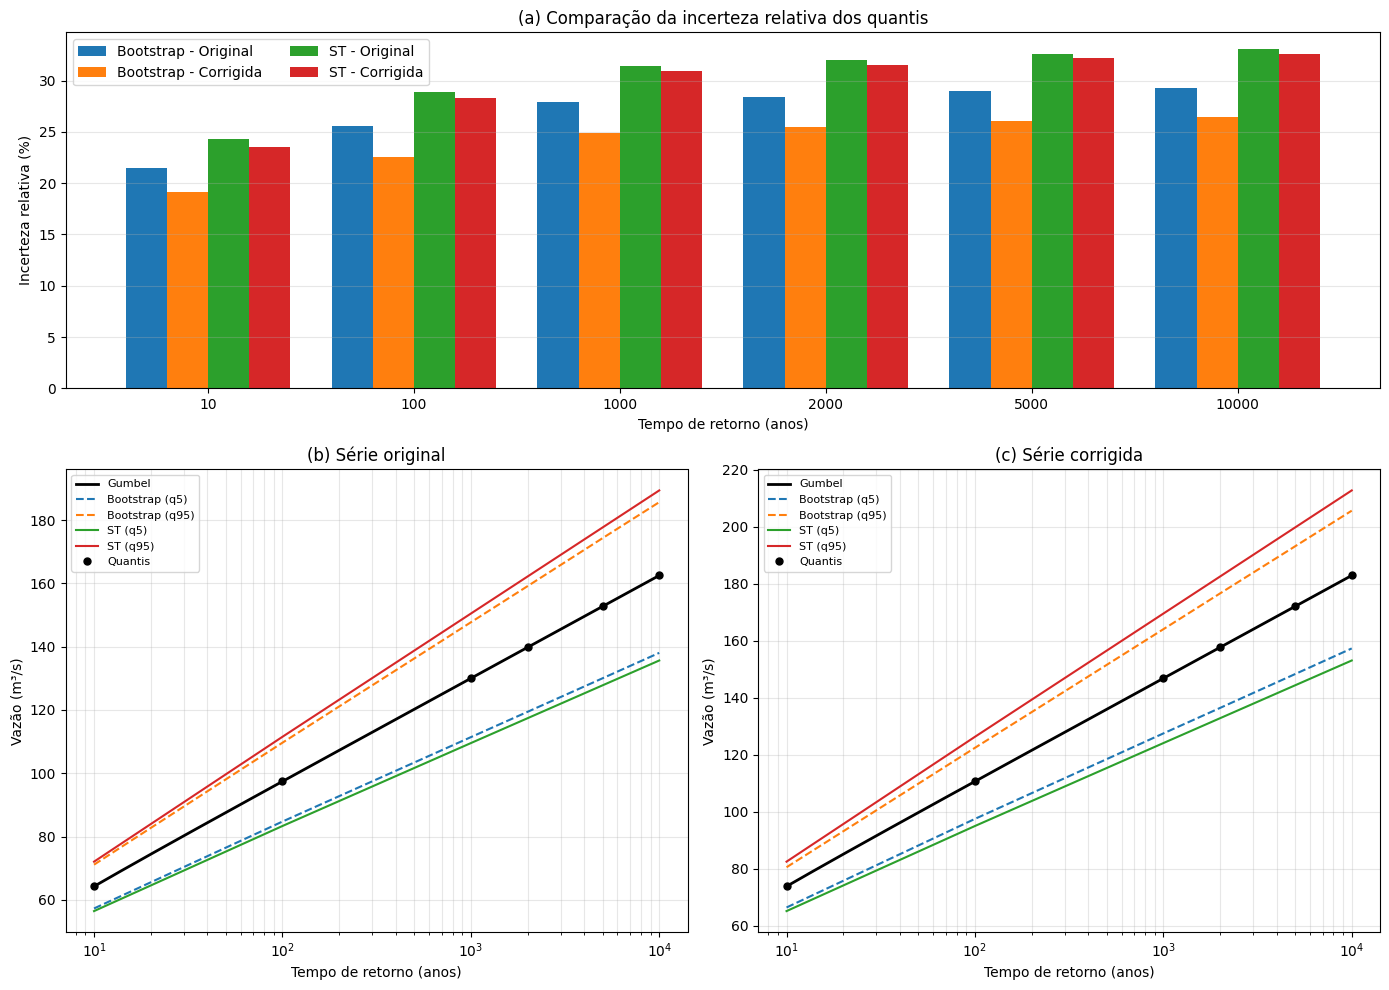

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r

# ==========================================================
# PARÂMETROS GUMBEL
# ==========================================================

alpha_orig = alfa_original
beta_orig  = beta_original

alpha_mod = alfa_corrigido
beta_mod  = beta_corrigido

# ==========================================================
# INCERTEZA RELATIVA (%)
# ==========================================================

inc_boot_orig = (
    (df_resumo['q95'] - df_resumo['q5'])
    / df_resumo['obs']
) * 100

inc_boot_mod = (
    (df_resumo2['q95'] - df_resumo2['q5'])
    / df_resumo2['obs']
) * 100

inc_st_orig = (
    (df_resumo['q95*'] - df_resumo['q5*'])
    / df_resumo['obs']
) * 100

inc_st_mod = (
    (df_resumo2['q95*'] - df_resumo2['q5*'])
    / df_resumo2['obs']
) * 100

# ==========================================================
# CURVAS GUMBEL
# ==========================================================

TR_cont = np.logspace(1, 4, 500)

Q_orig = gumbel_r.ppf(
    1 - 1/TR_cont,
    loc=beta_orig,
    scale=alpha_orig
)

Q_mod = gumbel_r.ppf(
    1 - 1/TR_cont,
    loc=beta_mod,
    scale=alpha_mod
)

# ==========================================================
# LAYOUT
# ==========================================================

fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[1, 1.3]
)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# ==========================================================
# (A) INCERTEZA RELATIVA
# ==========================================================

x = np.arange(len(df_resumo))
w = 0.20

ax1.bar(
    x - 1.5*w,
    inc_boot_orig,
    width=w,
    label='Bootstrap - Original'
)

ax1.bar(
    x - 0.5*w,
    inc_boot_mod,
    width=w,
    label='Bootstrap - Corrigida'
)

ax1.bar(
    x + 0.5*w,
    inc_st_orig,
    width=w,
    label='ST - Original'
)

ax1.bar(
    x + 1.5*w,
    inc_st_mod,
    width=w,
    label='ST - Corrigida'
)

ax1.set_xticks(x)
ax1.set_xticklabels(df_resumo['TR'])

ax1.set_xlabel('Tempo de retorno (anos)')
ax1.set_ylabel('Incerteza relativa (%)')

ax1.set_title(
    '(a) Comparação da incerteza relativa dos quantis'
)

ax1.grid(
    axis='y',
    alpha=0.3
)

ax1.legend(
    ncol=2,
    loc='upper left'
)

# ==========================================================
# (B) SÉRIE ORIGINAL
# ==========================================================

ax2.plot(
    TR_cont,
    Q_orig,
    color='black',
    linewidth=2,
    label='Gumbel'
)

# Bootstrap

ax2.plot(
    df_resumo['TR'],
    df_resumo['q5'],
    '--',
    linewidth=1.5,
    label='Bootstrap (q5)'
)

ax2.plot(
    df_resumo['TR'],
    df_resumo['q95'],
    '--',
    linewidth=1.5,
    label='Bootstrap (q95)'
)

# ST

ax2.plot(
    df_resumo['TR'],
    df_resumo['q5*'],

    linewidth=1.5,
    label='ST (q5)'
)

ax2.plot(
    df_resumo['TR'],
    df_resumo['q95*'],

    linewidth=1.5,
    label='ST (q95)'
)

# Quantis

ax2.plot(
    df_resumo['TR'],
    df_resumo['obs'],
    'ko',
    markersize=5,
    label='Quantis'
)

ax2.set_xscale('log')

ax2.set_xlabel('Tempo de retorno (anos)')
ax2.set_ylabel('Vazão (m³/s)')

ax2.set_title('(b) Série original')

ax2.grid(
    True,
    which='both',
    alpha=0.3
)

ax2.legend(
    fontsize=8
)

# ==========================================================
# (C) SÉRIE CORRIGIDA
# ==========================================================

ax3.plot(
    TR_cont,
    Q_mod,
    color='black',
    linewidth=2,
    label='Gumbel'
)

# Bootstrap

ax3.plot(
    df_resumo2['TR'],
    df_resumo2['q5'],
    '--',
    linewidth=1.5,
    label='Bootstrap (q5)'
)

ax3.plot(
    df_resumo2['TR'],
    df_resumo2['q95'],
    '--',
    linewidth=1.5,
    label='Bootstrap (q95)'
)

# ST

ax3.plot(
    df_resumo2['TR'],
    df_resumo2['q5*'],

    linewidth=1.5,
    label='ST (q5)'
)

ax3.plot(
    df_resumo2['TR'],
    df_resumo2['q95*'],

    linewidth=1.5,
    label='ST (q95)'
)

# Quantis

ax3.plot(
    df_resumo2['TR'],
    df_resumo2['obs'],
    'ko',
    markersize=5,
    label='Quantis'
)

ax3.set_xscale('log')

ax3.set_xlabel('Tempo de retorno (anos)')
ax3.set_ylabel('Vazão (m³/s)')

ax3.set_title('(c) Série corrigida')

ax3.grid(
    True,
    which='both',
    alpha=0.3
)

ax3.legend(
    fontsize=8
)

# ==========================================================
# AJUSTES FINAIS
# ==========================================================

plt.tight_layout()

plt.savefig(
    'comparacao_ic_gumbel.png',
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    r'C:\Users\mateu\OneDrive\Área de Trabalho\artigos_2026\analise_incerteza\analise_incerteza.png',
    dpi=600,
    bbox_inches='tight'
)

plt.savefig("C:\\Users\\mateu\\OneDrive\\Área de Trabalho\\artigos_2026\\analise_incerteza\\analise_incerteza.png")

In [14]:
print(serie_corrigida['streamflow_corrigida'].mean())
print(serie_corrigida['streamflow_m3s'].mean())

47.60930167062914
40.6989141025641


In [16]:
print(serie_corrigida['streamflow_corrigida'].std())
print(serie_corrigida['streamflow_m3s'].std())

19.299107998509957
17.641039020632004


In [ ]:
print(serie_corrigida['streamflow_corrigida'].std())
print(serie_corrigida['streamflow_m3s'].std())

In [18]:
df_resumo2['dif'] = (df_resumo2['incerteza']-df_resumo2['incerteza*'])/df_resumo2['incerteza']

In [20]:
df_resumo2['dif'].mean()

-0.2390263184085851

In [22]:
df_resumo['dif'] = (df_resumo['incerteza']-df_resumo['incerteza*'])/df_resumo['incerteza']

In [23]:
df_resumo

,TR,obs,q95,q5,incerteza,w,st,q95*,q5*,incerteza*,dif
0,10,64.302282,71.159811,57.327283,21.511721,2.250367,3.982617,72.108211,56.496354,24.278854,-0.128634
1,100,97.450650,109.669787,84.767314,25.553932,4.600149,7.186683,111.536549,83.364752,28.908783,-0.131285
2,1000,129.996988,147.689839,111.422014,27.898973,6.907255,10.432698,150.445075,109.548900,31.459325,-0.127616
3,2000,139.778743,159.110610,119.422262,28.393694,7.600652,11.414964,162.152072,117.405413,32.012492,-0.127451
4,5000,152.706971,174.261246,130.013649,28.975493,8.517093,12.715867,177.630070,127.783872,32.641731,-0.126529
5,10000,162.485902,185.634327,138.045732,29.287830,9.210290,13.701411,189.340668,135.631135,33.054888,-0.128622


In [26]:
df_resumo2

,TR,obs,q95,q5,incerteza,w,st,q95*,q5*,incerteza*,dif
0,10,73.842766,80.557843,66.433812,19.127171,2.250367,4.426395,82.518500,65.167032,23.497858,-0.228507
1,100,110.684819,122.469848,97.528939,22.533270,4.600149,7.987487,126.340293,95.029345,28.288385,-0.255405
2,1000,146.857758,164.096755,127.522359,24.904640,6.907255,11.595201,169.584352,124.131163,30.950486,-0.242760
3,2000,157.729482,176.664054,136.471276,25.482096,7.600652,12.686920,182.595846,132.863119,31.530394,-0.237355
4,5000,172.098288,193.186391,148.343681,26.056454,8.517093,14.132781,199.798539,144.398037,32.191199,-0.235441
5,10000,182.966874,205.706925,157.359334,26.424232,9.210290,15.228144,212.814037,153.119712,32.625755,-0.234691


In [25]:
alfa_corrigido

15.678924580435643

In [27]:
alfa_original

14.106997905230868